## CKD Dataset Project ML Modeling

#### import Librires

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Reasing Dataset

In [8]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
test_file_path = "Testing_CKD_dataset.csv"
train_file_path = "Training_CKD_dataset.csv"

# Load the latest version
df_train = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "priyankabarik/chronic-kidney-disease-ckd-clinical-dataset",
  train_file_path
)

df_test = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "priyankabarik/chronic-kidney-disease-ckd-clinical-dataset",
  test_file_path
)

display(df_train.head())
display(df_test.head())

C:\Users\LAP X\AppData\Local\Temp\ipykernel_31100\3521928.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_train = kagglehub.load_dataset(
C:\Users\LAP X\AppData\Local\Temp\ipykernel_31100\3521928.py:17: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_test = kagglehub.load_dataset(


,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,97,69,99,0,12,95,...,96,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes
1,Severe CKD (Stage 4),43,0,18,165,100,67,5,87,28,...,88,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No
2,Healthy Kidney,77,0,32,116,63,101,0,16,100,...,82,9.114854,246,299,4,7.083558,No,No,Yes,No
3,Healthy Kidney,83,0,24,93,75,87,0,10,101,...,82,7.286450,173,285,4,6.428780,Yes,No,No,Yes
4,Healthy Kidney,38,1,19,111,70,92,0,10,102,...,106,8.376492,266,294,4,7.852894,Yes,No,Yes,No


,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,38,0,33,114,78,78,0,10,117,...,97,4.677411,211,203,4,5.156141,No,No,Yes,No
1,Severe CKD (Stage 4),76,0,28,166,103,92,5,84,25,...,111,9.490302,194,210,2,7.922118,No,No,No,No
2,Healthy Kidney,63,0,33,109,79,98,0,17,109,...,125,6.023745,243,138,4,6.606848,No,No,No,Yes
3,Healthy Kidney,54,0,31,107,62,109,0,10,107,...,127,5.772014,163,276,4,6.651897,No,Yes,No,Yes
4,Healthy Kidney,20,0,20,111,63,92,0,17,97,...,127,8.483288,221,264,4,6.400641,No,Yes,Yes,No


In [9]:
# df_train = pd.read_csv('Testing_CKD_dataset.csv')

In [10]:
# df_test = pd.read_csv('Testing_CKD_dataset.csv')

### EDA

In [11]:
df_train.head()

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,97,69,99,0,12,95,...,96,7.547874,204,120,4,7.091259,Yes,Yes,Yes,Yes
1,Severe CKD (Stage 4),43,0,18,165,100,67,5,87,28,...,88,7.287338,166,277,2,7.875167,Yes,Yes,Yes,No
2,Healthy Kidney,77,0,32,116,63,101,0,16,100,...,82,9.114854,246,299,4,7.083558,No,No,Yes,No
3,Healthy Kidney,83,0,24,93,75,87,0,10,101,...,82,7.286450,173,285,4,6.428780,Yes,No,No,Yes
4,Healthy Kidney,38,1,19,111,70,92,0,10,102,...,106,8.376492,266,294,4,7.852894,Yes,No,Yes,No


### Checking Nulls

In [12]:
df_train.isnull().sum()

Target                      0
Age                         0
Gender                      0
BMI                         0
Systolic_BP                 0
Diastolic_BP                0
Heart_Rate                  0
Serum_Creatinine            0
Blood_Urea_Nitrogen         0
eGFR                        0
Urine_Albumin               0
Urine_Protein               0
Albumin_Creatinine_Ratio    0
Urine_Specific_Gravity      0
Sodium                      0
Potassium                   0
Calcium                     0
Phosphorus                  0
Chloride                    0
Bicarbonate                 0
Hemoglobin                  0
RBC_Count                   0
WBC_Count                   0
Platelet_Count              0
Packed_Cell_Volume          0
Blood_Glucose_Random        0
Fasting_Glucose             0
HbA1c                       0
Cholesterol                 0
Triglycerides               0
Serum_Albumin               0
Total_Protein               0
Diabetes                    0
Hypertensi

In [13]:
df_train.describe()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,Urine_Albumin,...,WBC_Count,Platelet_Count,Packed_Cell_Volume,Blood_Glucose_Random,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,...,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,51.951905,0.500619,25.977571,113.497619,75.280857,84.280714,0.629571,21.682048,91.426095,59.986905,...,7493.323000,300422.551571,42.167238,134.330524,99.473762,6.998247,214.411762,199.511571,3.598048,6.507856
std,18.796090,0.500012,4.890439,19.151820,12.106952,14.387748,1.482399,20.800122,26.787045,136.148540,...,2019.807219,86546.236256,5.496877,37.623833,17.300907,1.736593,37.451581,58.167742,0.764034,0.865395
min,20.000000,0.000000,18.000000,90.000000,60.000000,60.000000,0.000000,7.000000,5.000000,0.000000,...,4000.000000,150022.000000,20.000000,70.000000,70.000000,4.000855,150.000000,100.000000,1.000000,5.000065
25%,36.000000,0.000000,22.000000,99.000000,66.000000,72.000000,0.000000,11.000000,89.000000,6.000000,...,5738.000000,225571.000000,40.000000,102.000000,84.000000,5.509804,182.000000,149.000000,3.000000,5.757357
50%,52.000000,1.000000,26.000000,110.000000,73.000000,84.000000,0.000000,15.000000,99.000000,13.000000,...,7504.000000,300718.000000,43.000000,134.000000,99.000000,7.002234,214.000000,199.000000,4.000000,6.520847
75%,68.000000,1.000000,30.000000,120.000000,80.000000,97.000000,1.000000,20.000000,109.000000,20.000000,...,9234.000000,375397.250000,46.000000,167.000000,114.000000,8.501457,247.000000,250.000000,4.000000,7.254656
max,84.000000,1.000000,34.000000,189.000000,119.000000,109.000000,9.000000,149.000000,119.000000,999.000000,...,10999.000000,449942.000000,49.000000,199.000000,129.000000,9.999904,279.000000,299.000000,4.000000,7.999568


In [14]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Target                    21000 non-null  str    
 1   Age                       21000 non-null  int64  
 2   Gender                    21000 non-null  int64  
 3   BMI                       21000 non-null  int64  
 4   Systolic_BP               21000 non-null  int64  
 5   Diastolic_BP              21000 non-null  int64  
 6   Heart_Rate                21000 non-null  int64  
 7   Serum_Creatinine          21000 non-null  int64  
 8   Blood_Urea_Nitrogen       21000 non-null  int64  
 9   eGFR                      21000 non-null  int64  
 10  Urine_Albumin             21000 non-null  int64  
 11  Urine_Protein             21000 non-null  int64  
 12  Albumin_Creatinine_Ratio  21000 non-null  int64  
 13  Urine_Specific_Gravity    21000 non-null  float64
 14  Sodium           

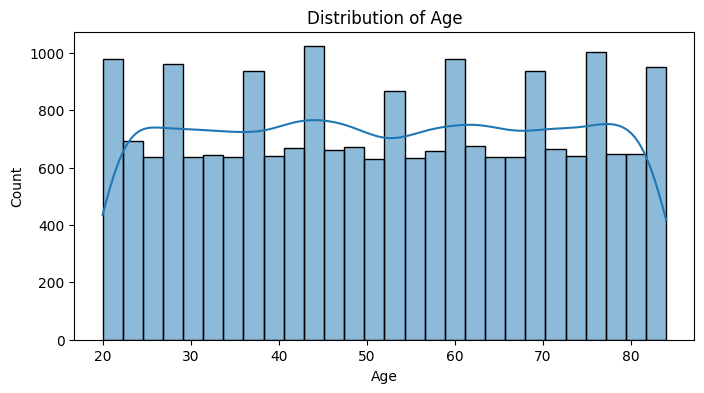

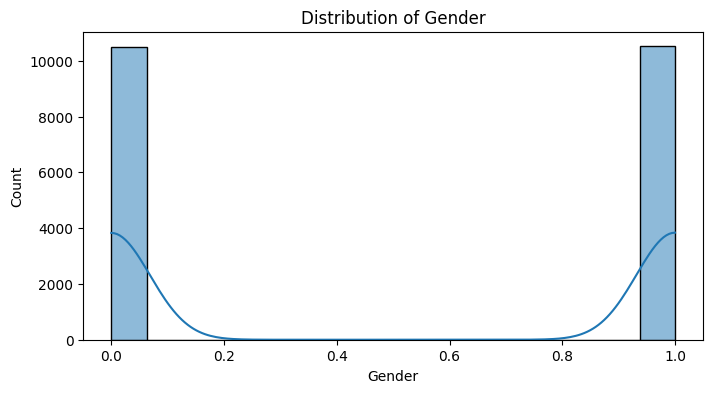

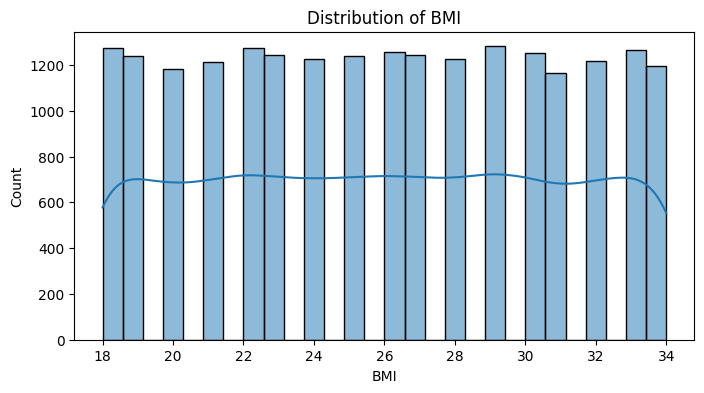

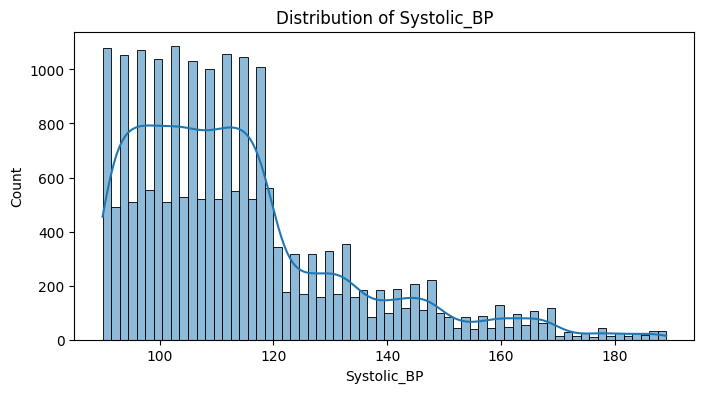

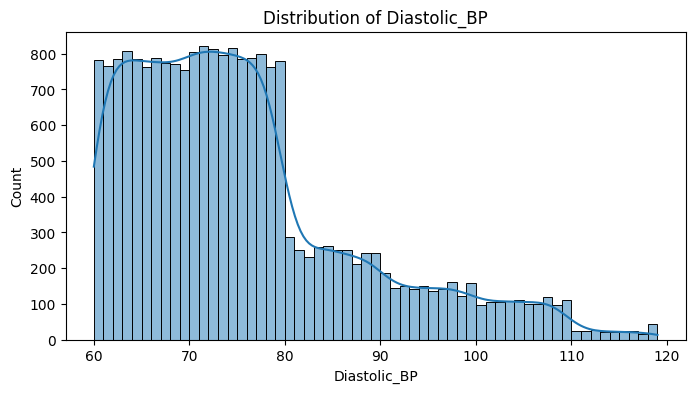

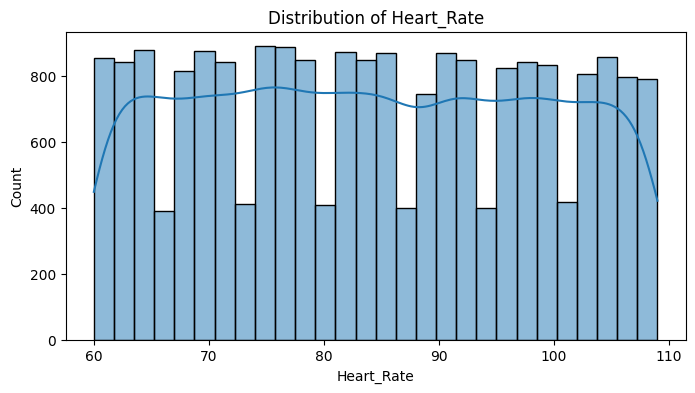

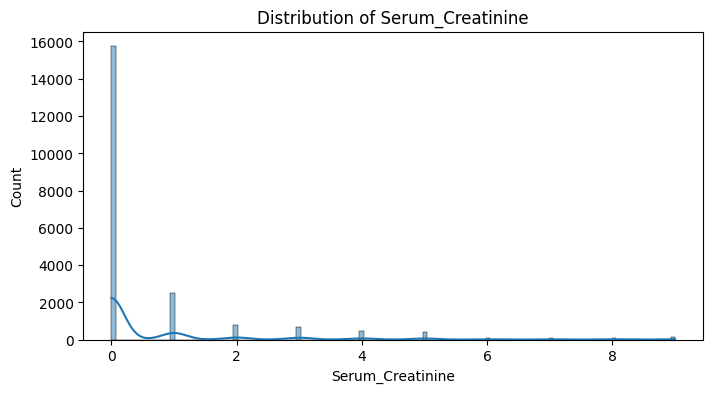

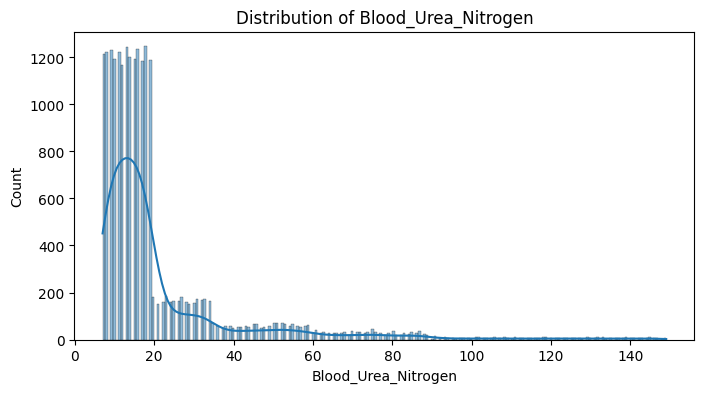

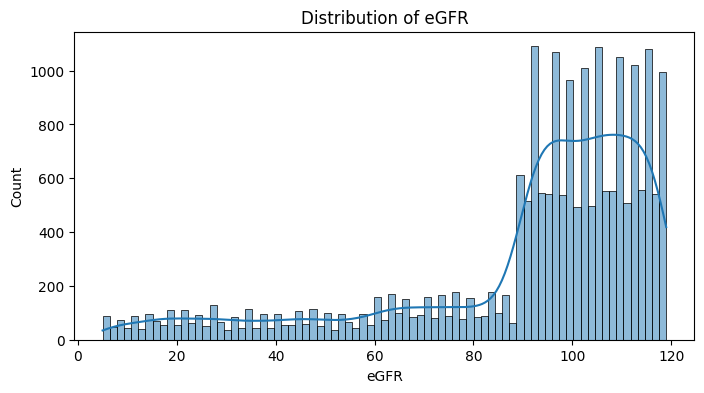

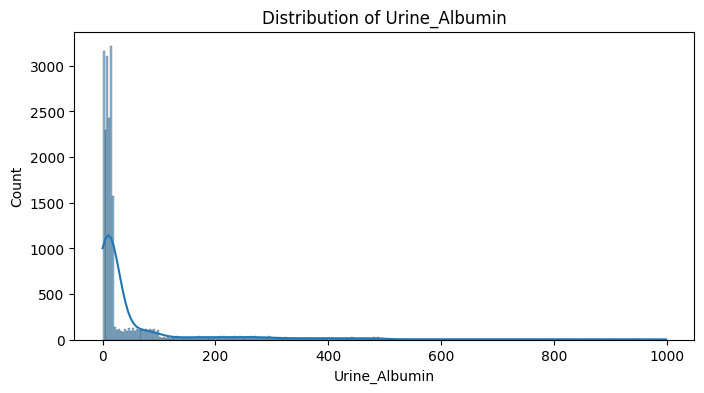

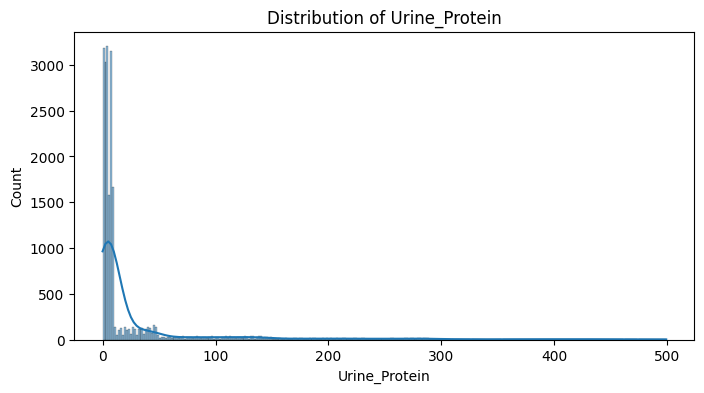

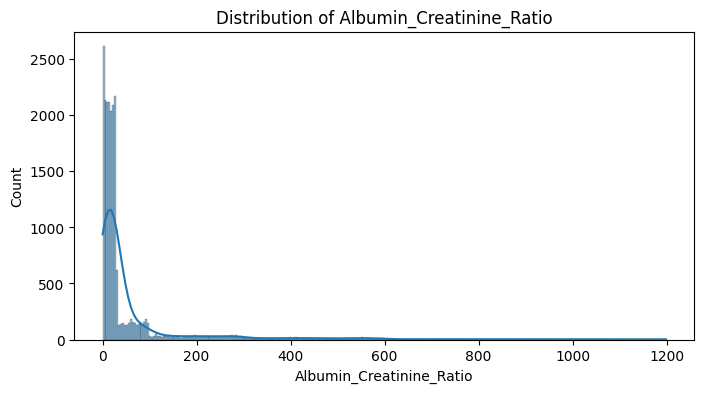

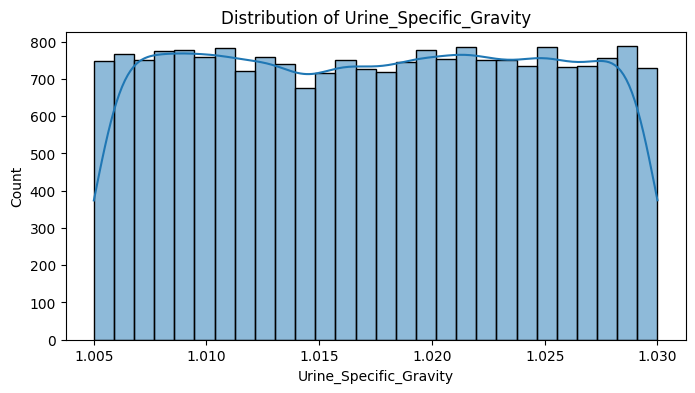

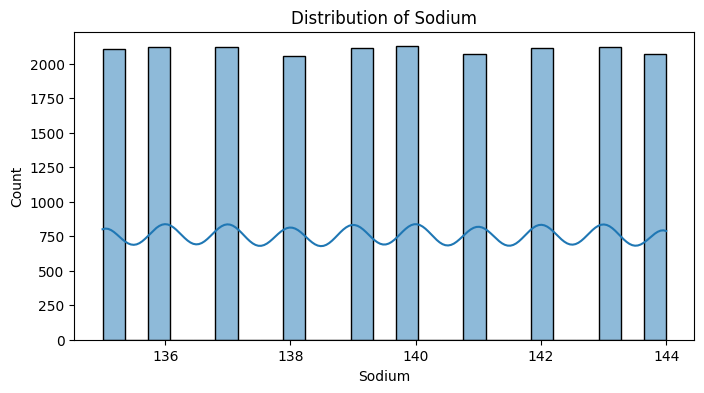

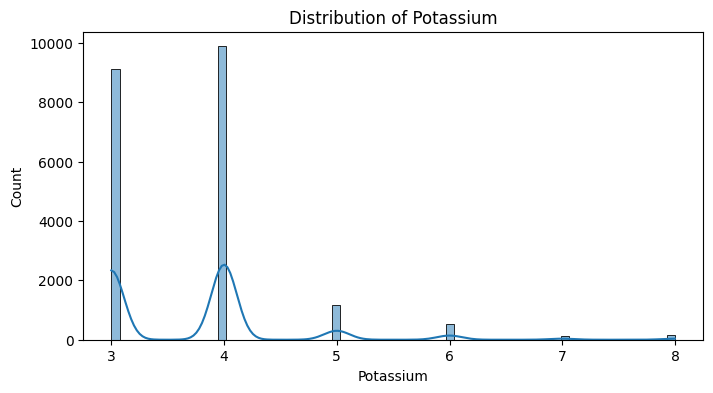

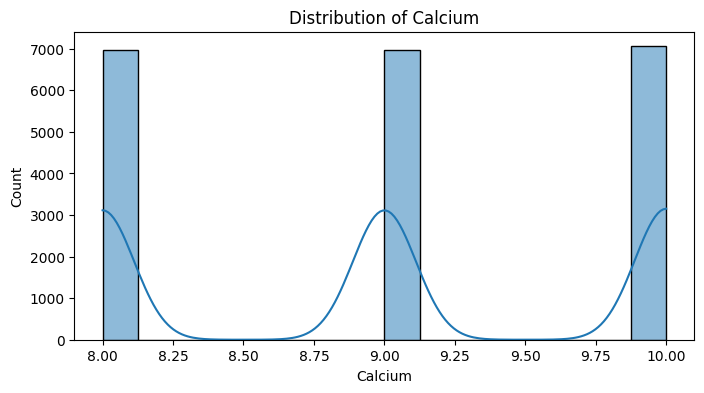

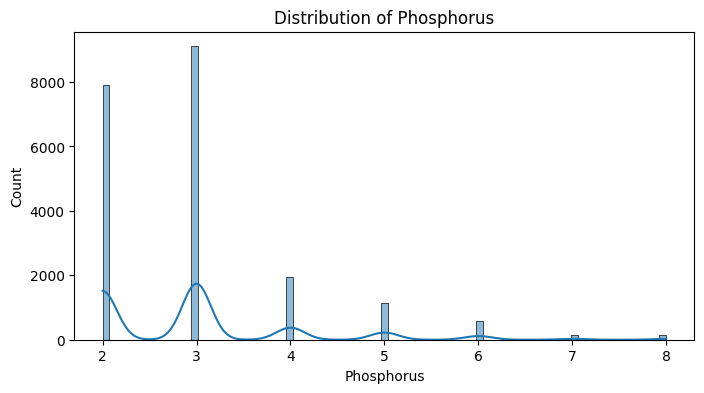

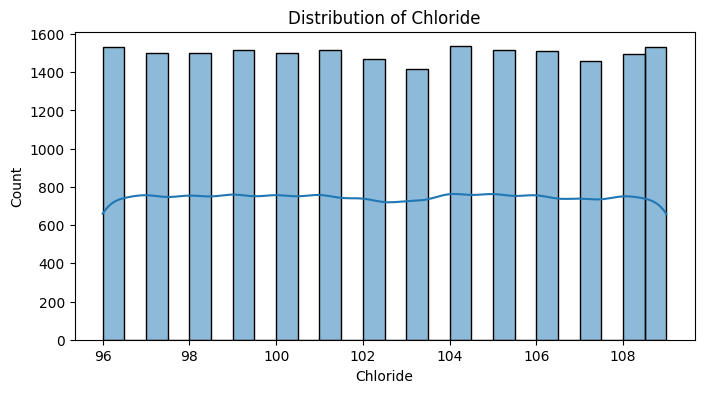

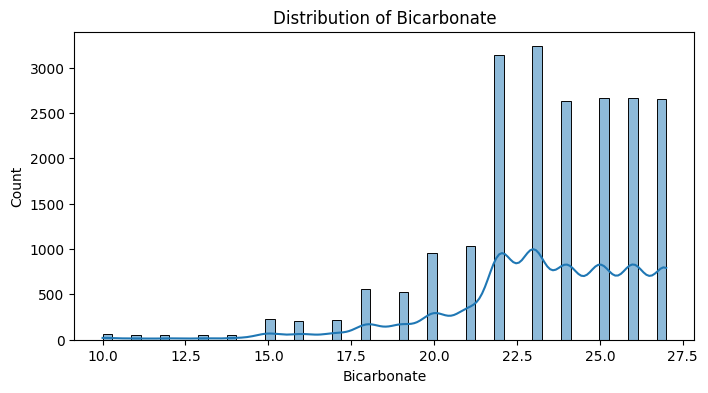

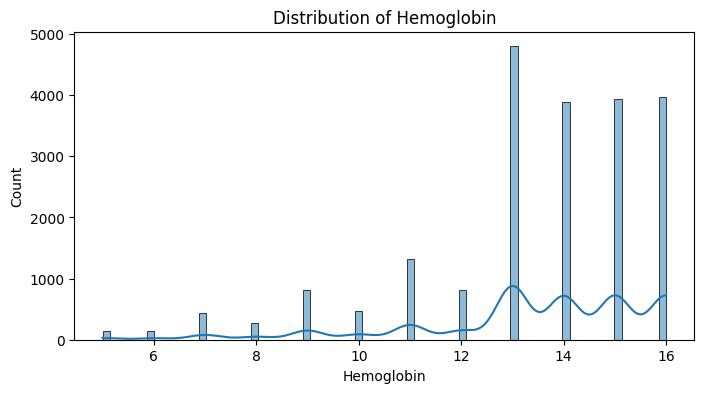

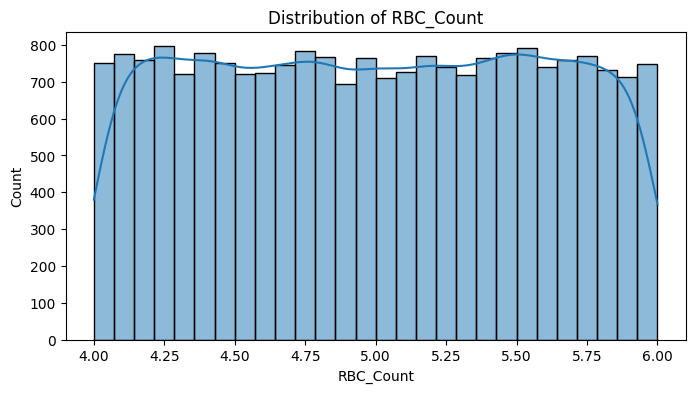

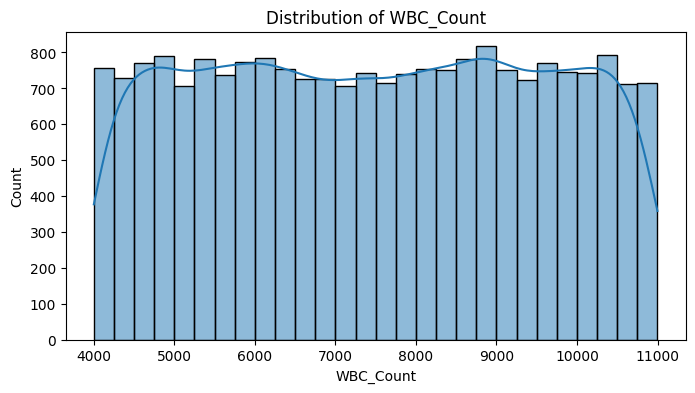

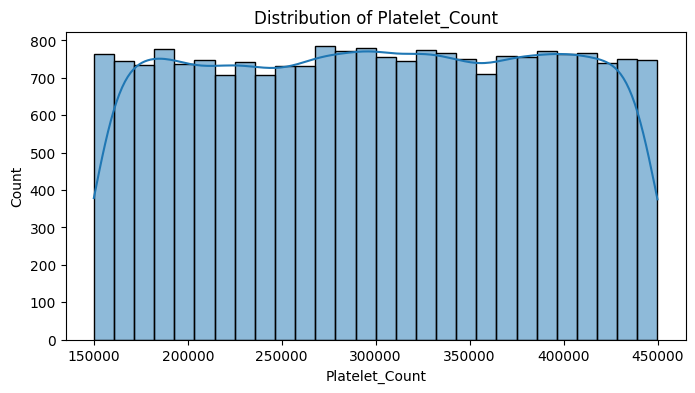

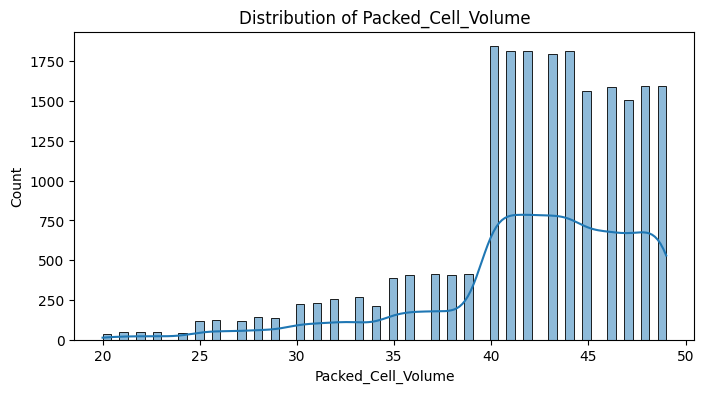

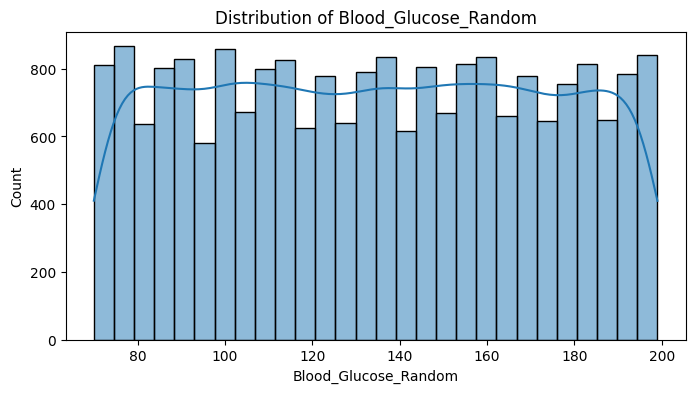

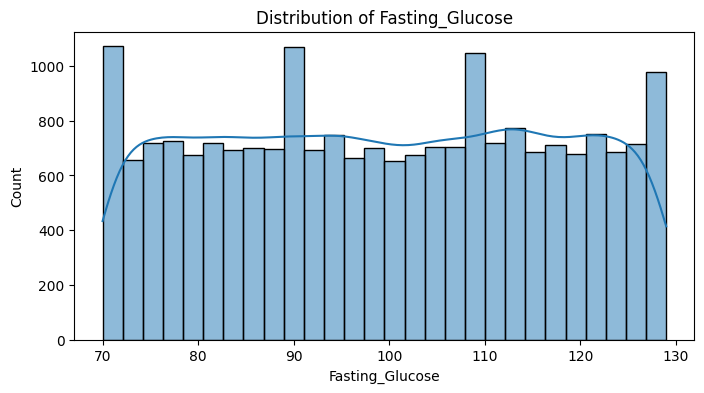

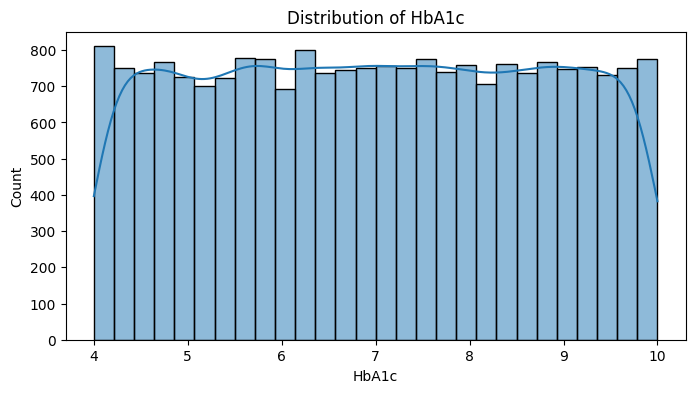

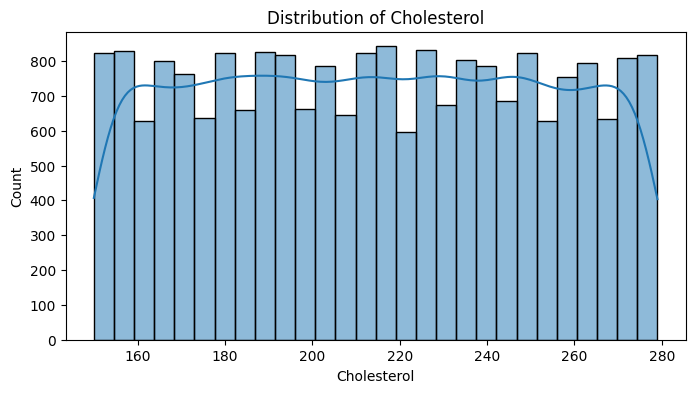

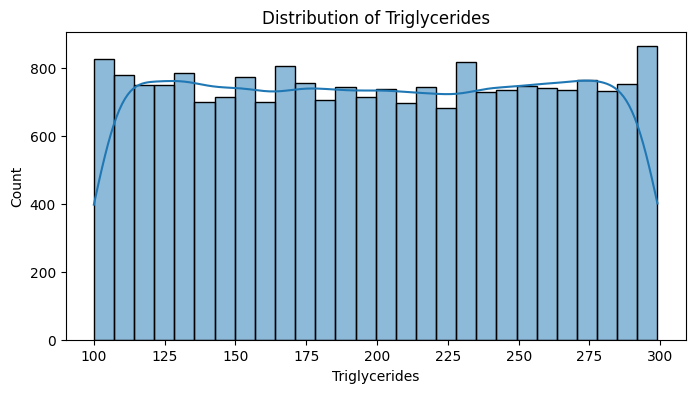

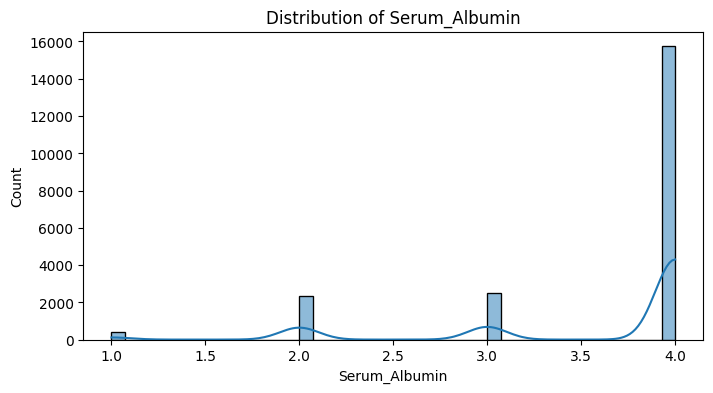

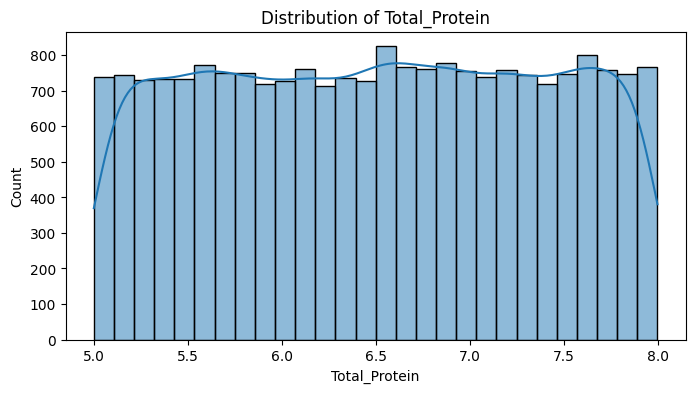

In [15]:
#plot distribution of all numeric features
numeric_features = df_train.select_dtypes(include=[np.number]).columns
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_train[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()

### it seem that data is tends to both `left skeweness` and `uniform distruption`

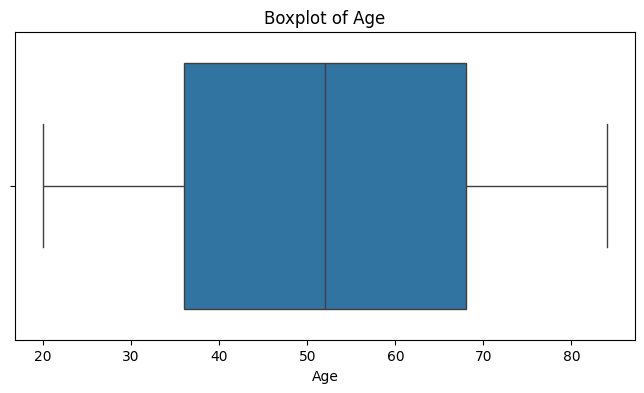

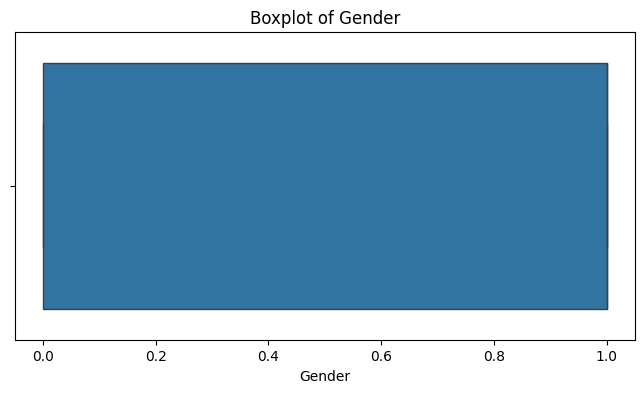

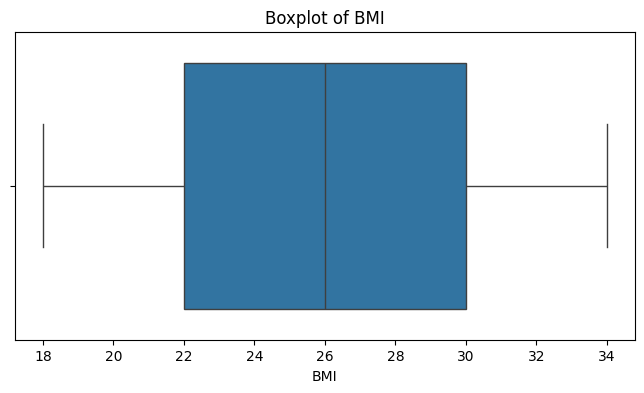

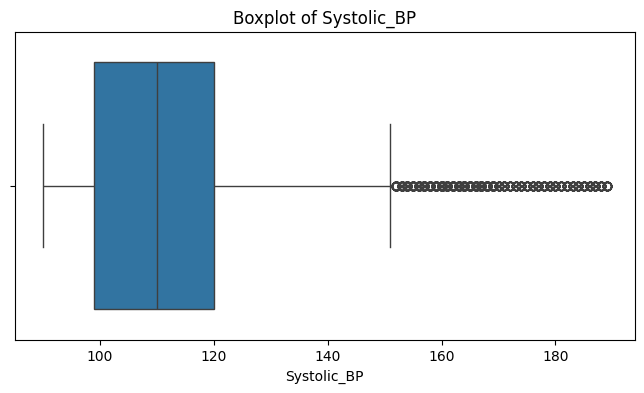

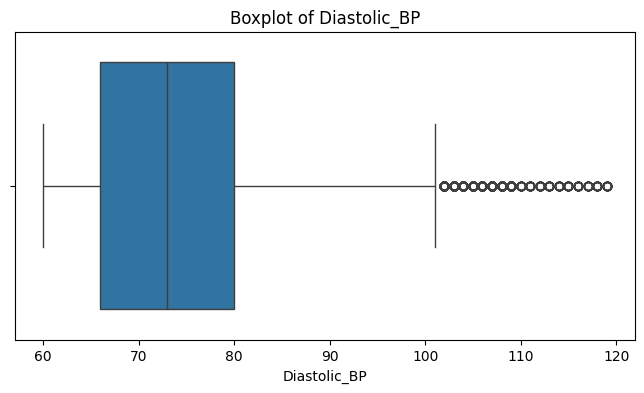

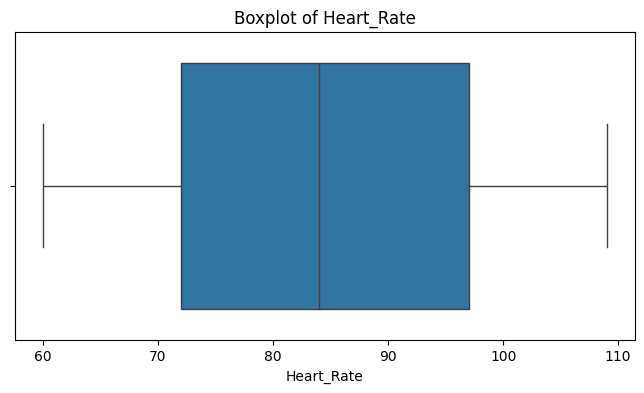

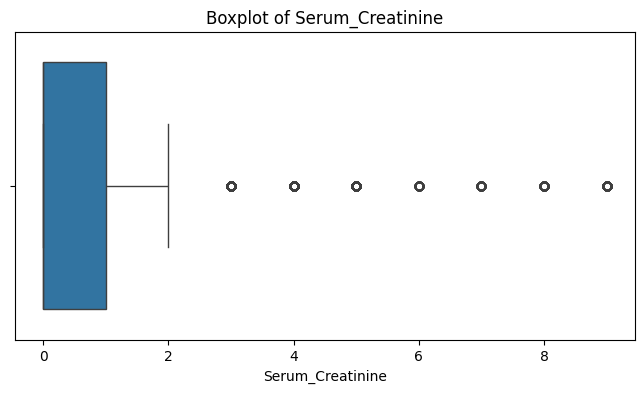

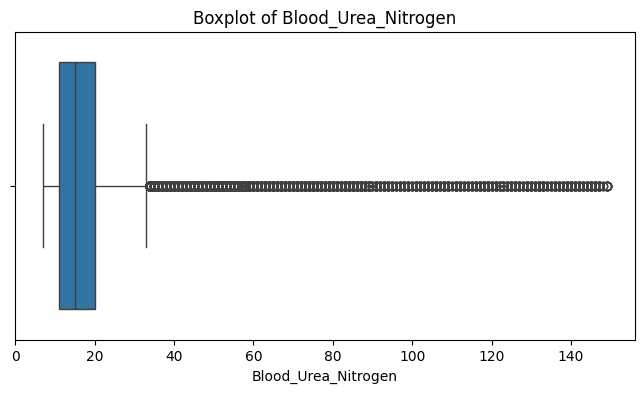

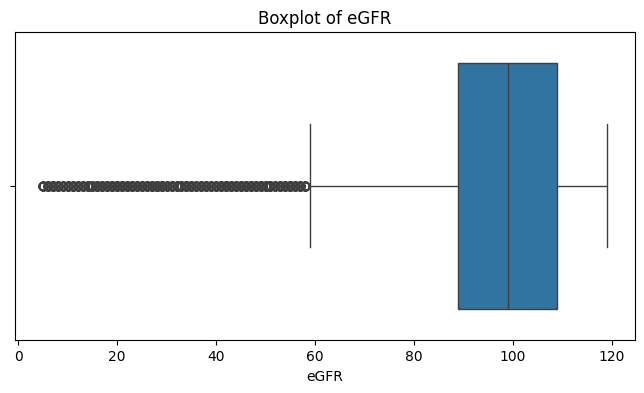

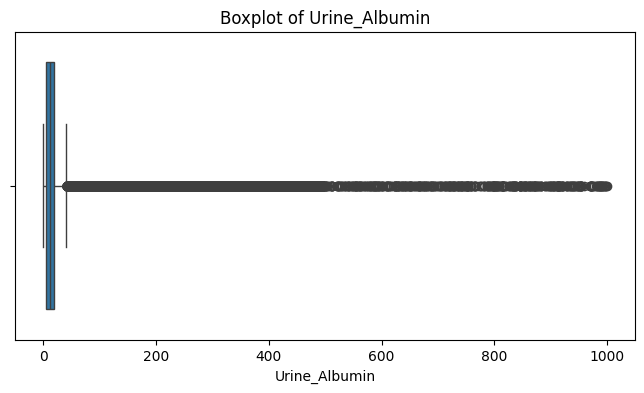

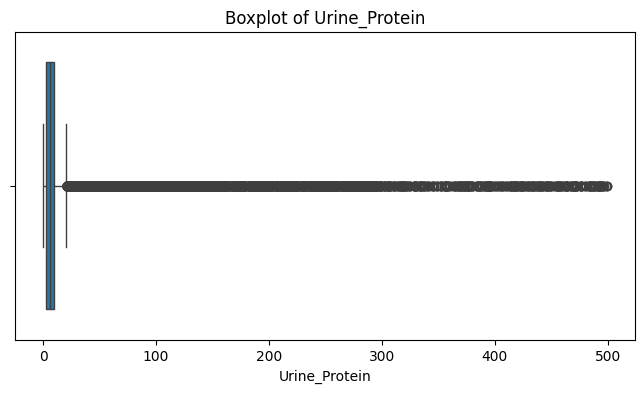

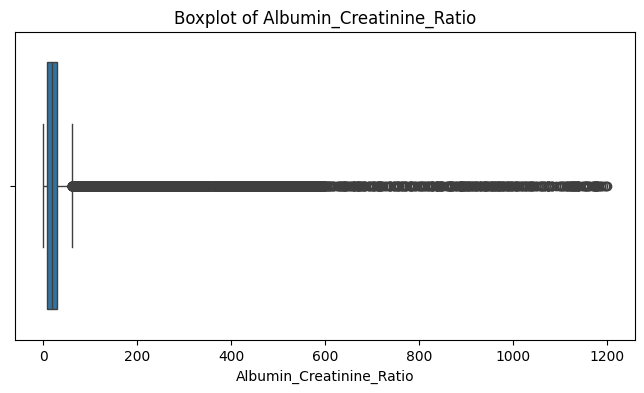

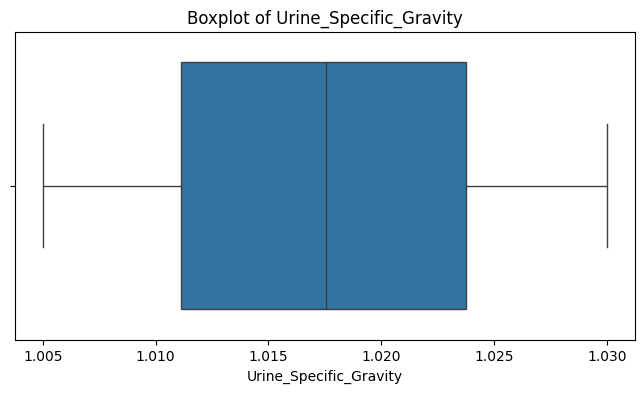

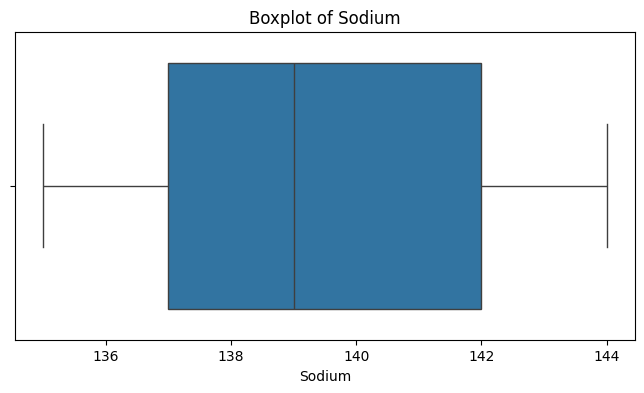

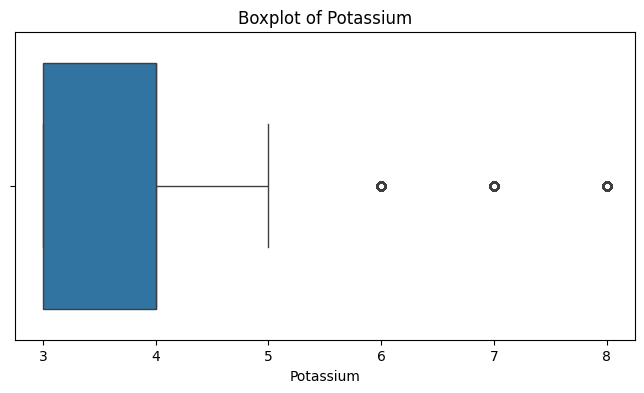

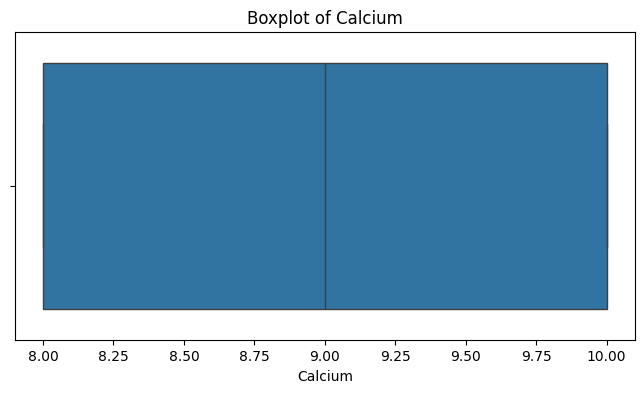

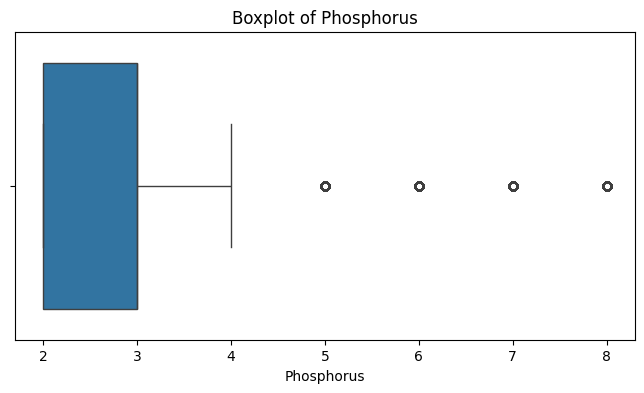

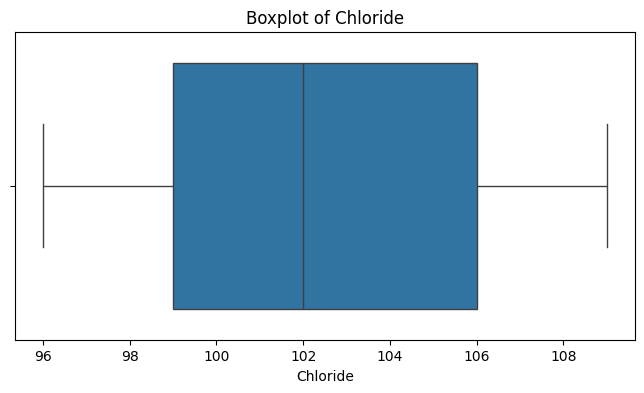

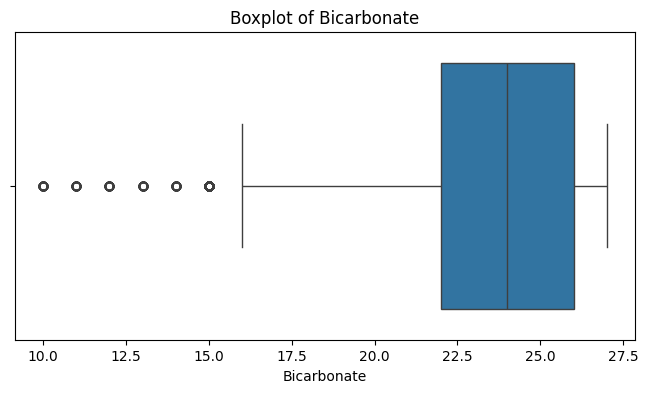

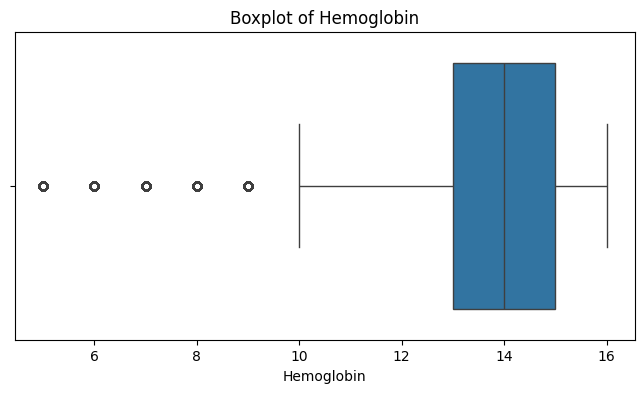

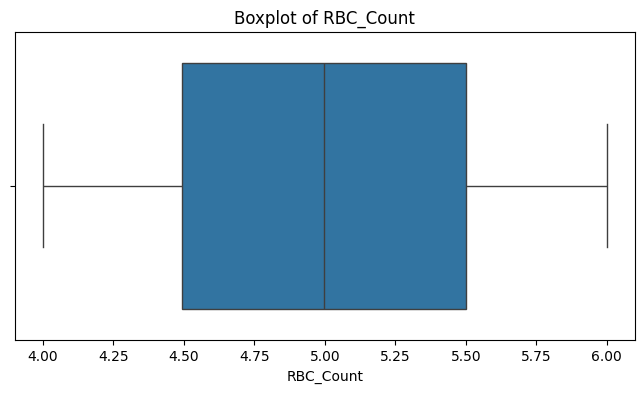

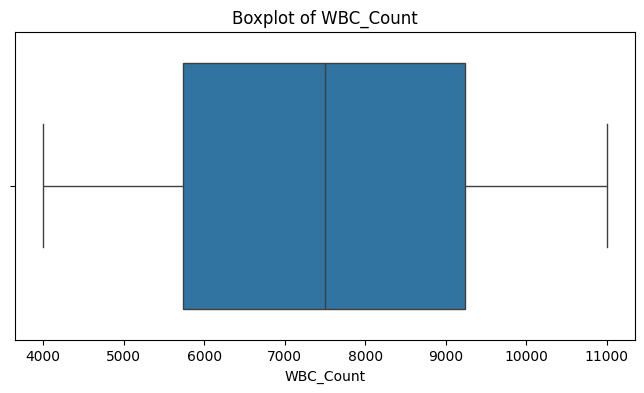

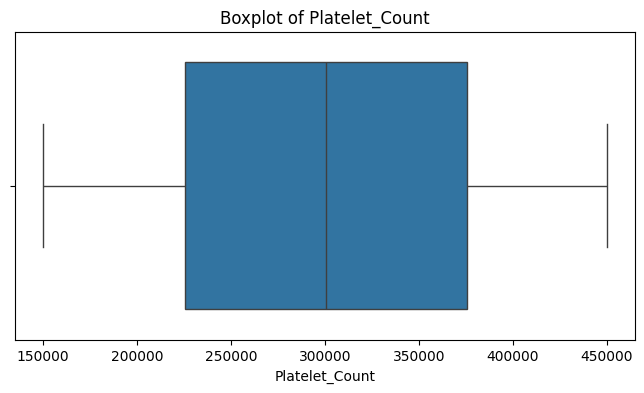

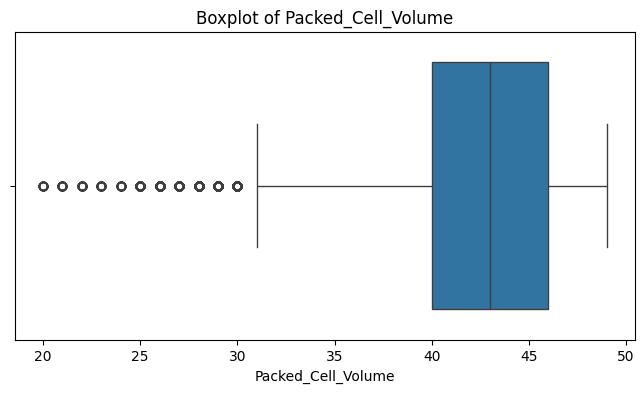

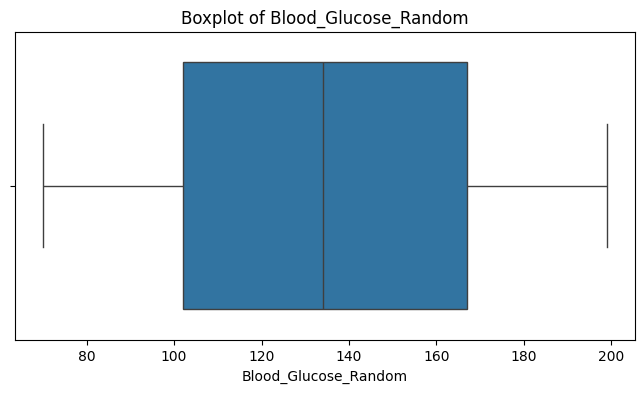

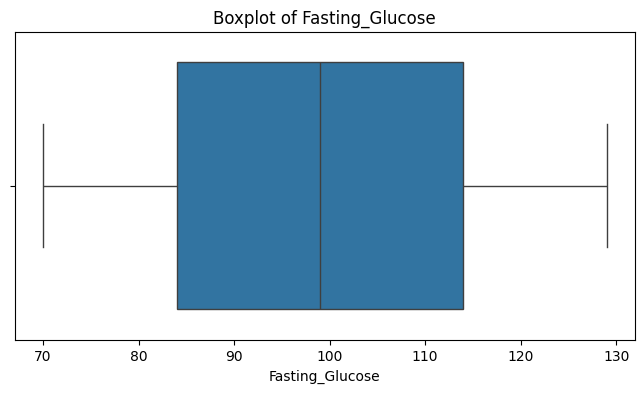

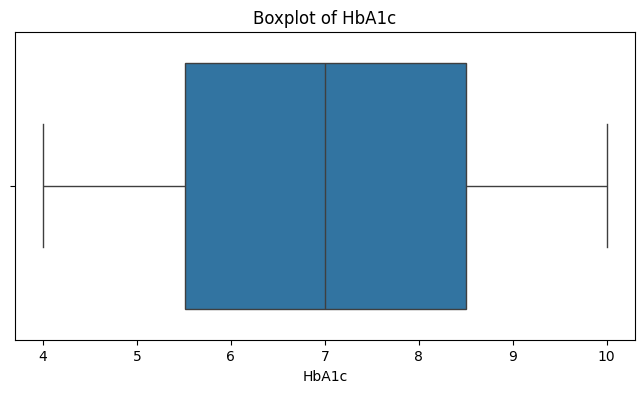

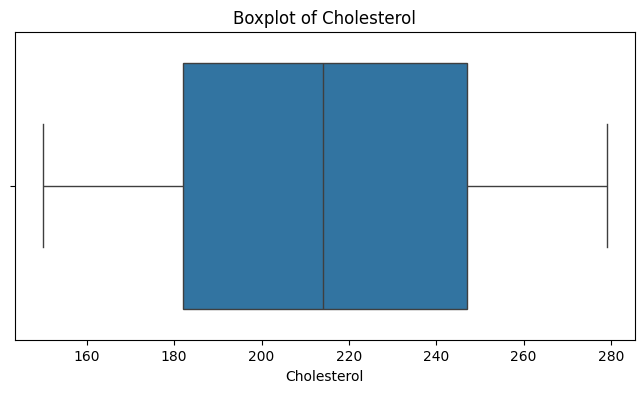

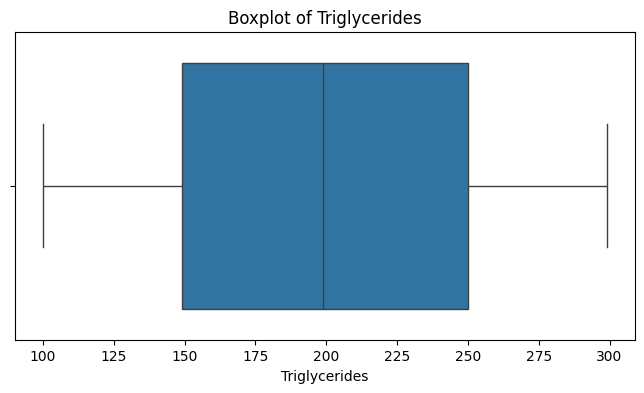

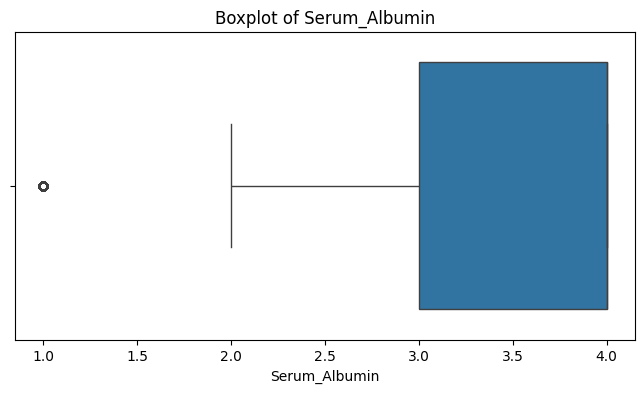

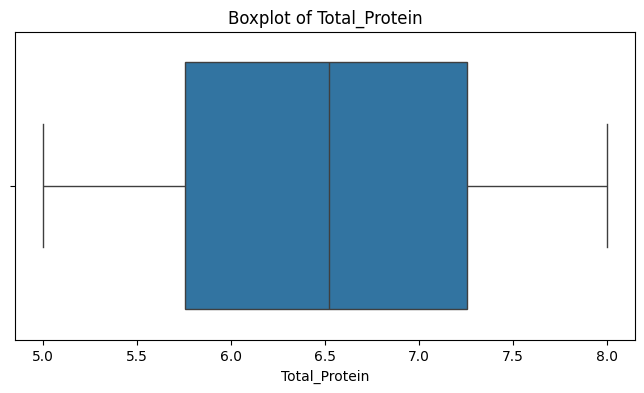

In [16]:
#Check for outliers using boxplots
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_train[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

In [17]:
#Apply log transformation to skewed features
# 1. Systolic_BP
# 2. Diastolic_BP
# 3. Blood_Urea_Nitrogen
# 4. eGFR
# 5. Urine_Albumin
# 6. Urine_Protein
# 7. Albumin_Creatinine_Ratio
skewed_features = ['Systolic_BP', 'Diastolic_BP', 'Blood_Urea_Nitrogen', 'eGFR', 'Urine_Albumin', 'Urine_Protein', 'Albumin_Creatinine_Ratio']
for feature in skewed_features:
    df_train[feature] = np.log1p(df_train[feature])

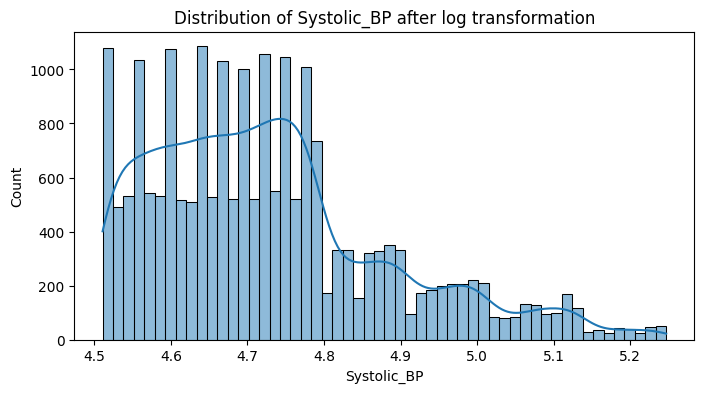

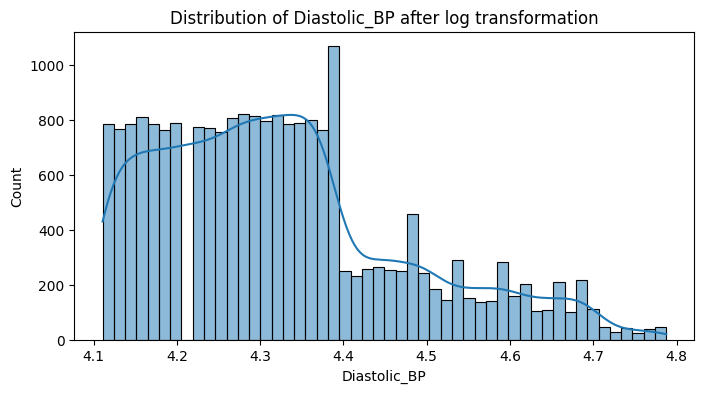

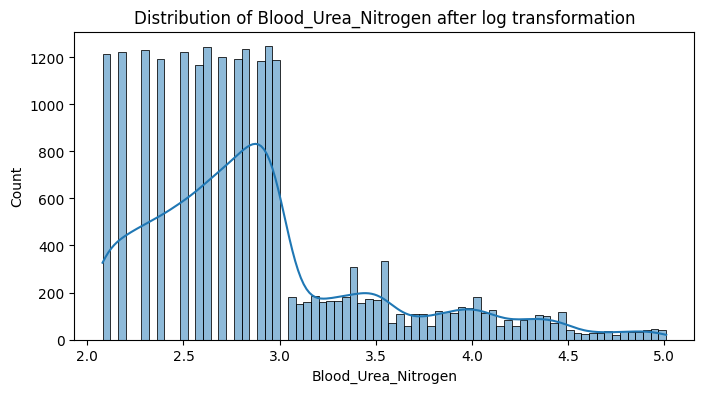

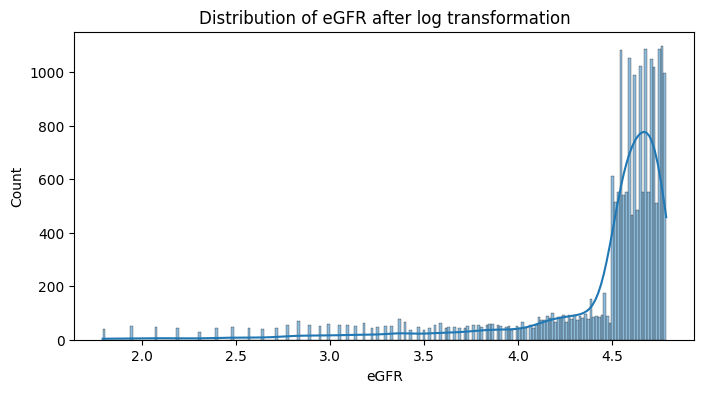

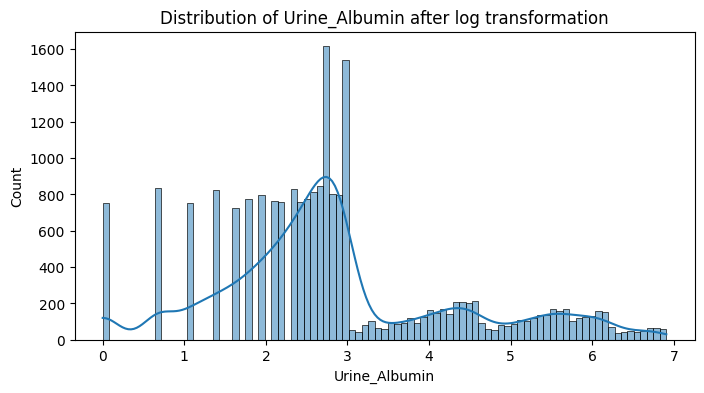

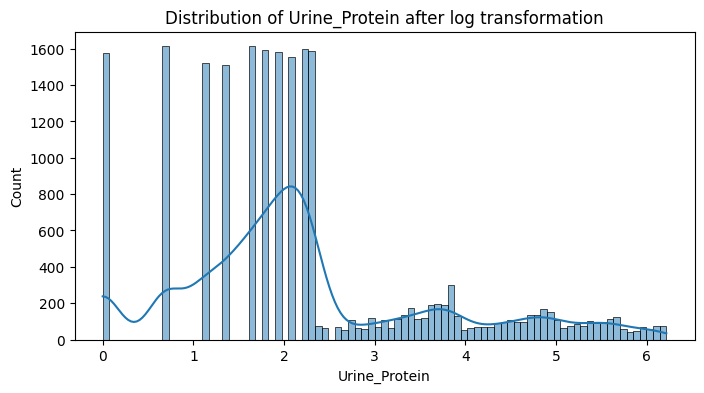

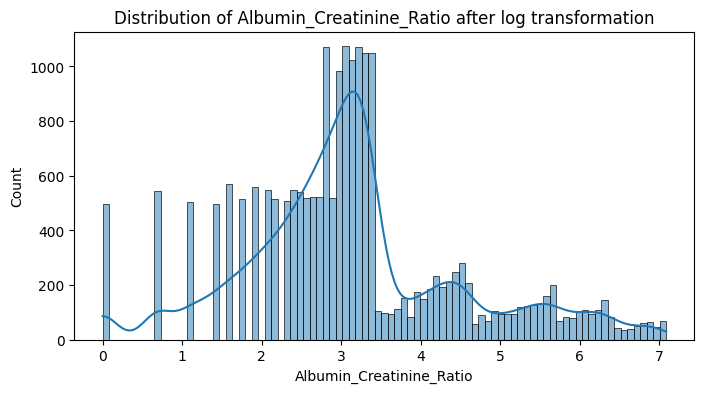

In [18]:
#plotting the ditribution of the skewed features after log transformation
for feature in skewed_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_train[feature], kde=True)
    plt.title(f'Distribution of {feature} after log transformation')
    plt.show()

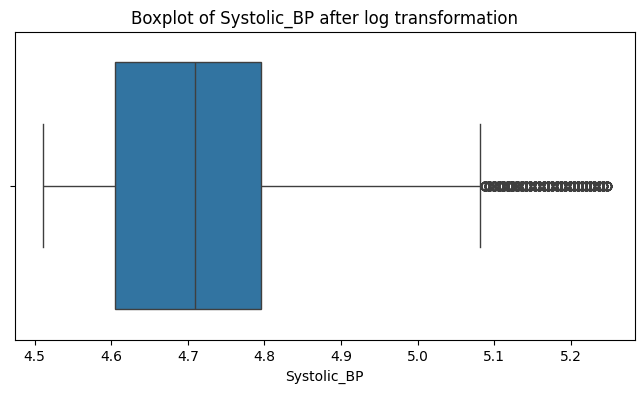

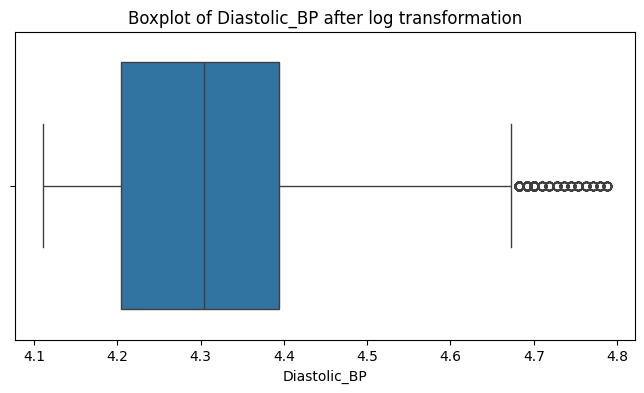

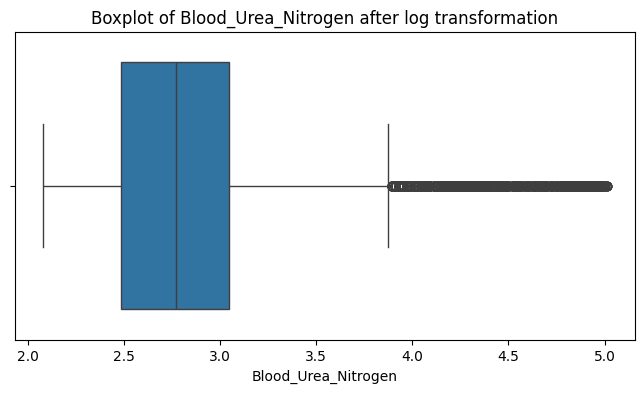

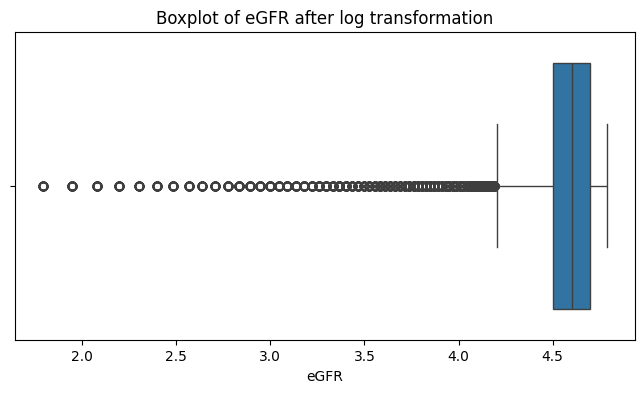

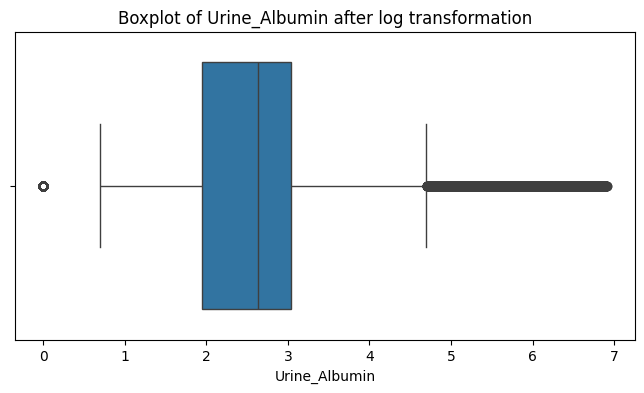

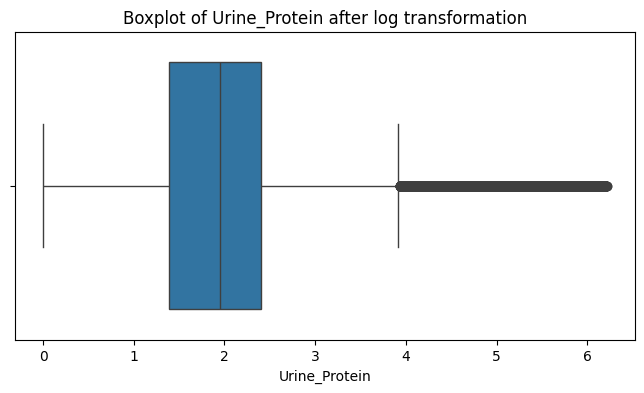

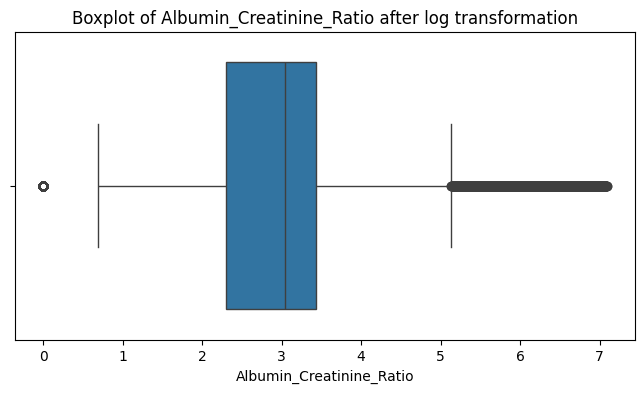

In [19]:
#Draw boxplots for the skewed features after log transformation
for feature in skewed_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_train[feature])
    plt.title(f'Boxplot of {feature} after log transformation')
    plt.show()

### okay it seem that the effect of outlier data is become less

## Feature Engineering

### Now,Check correlation

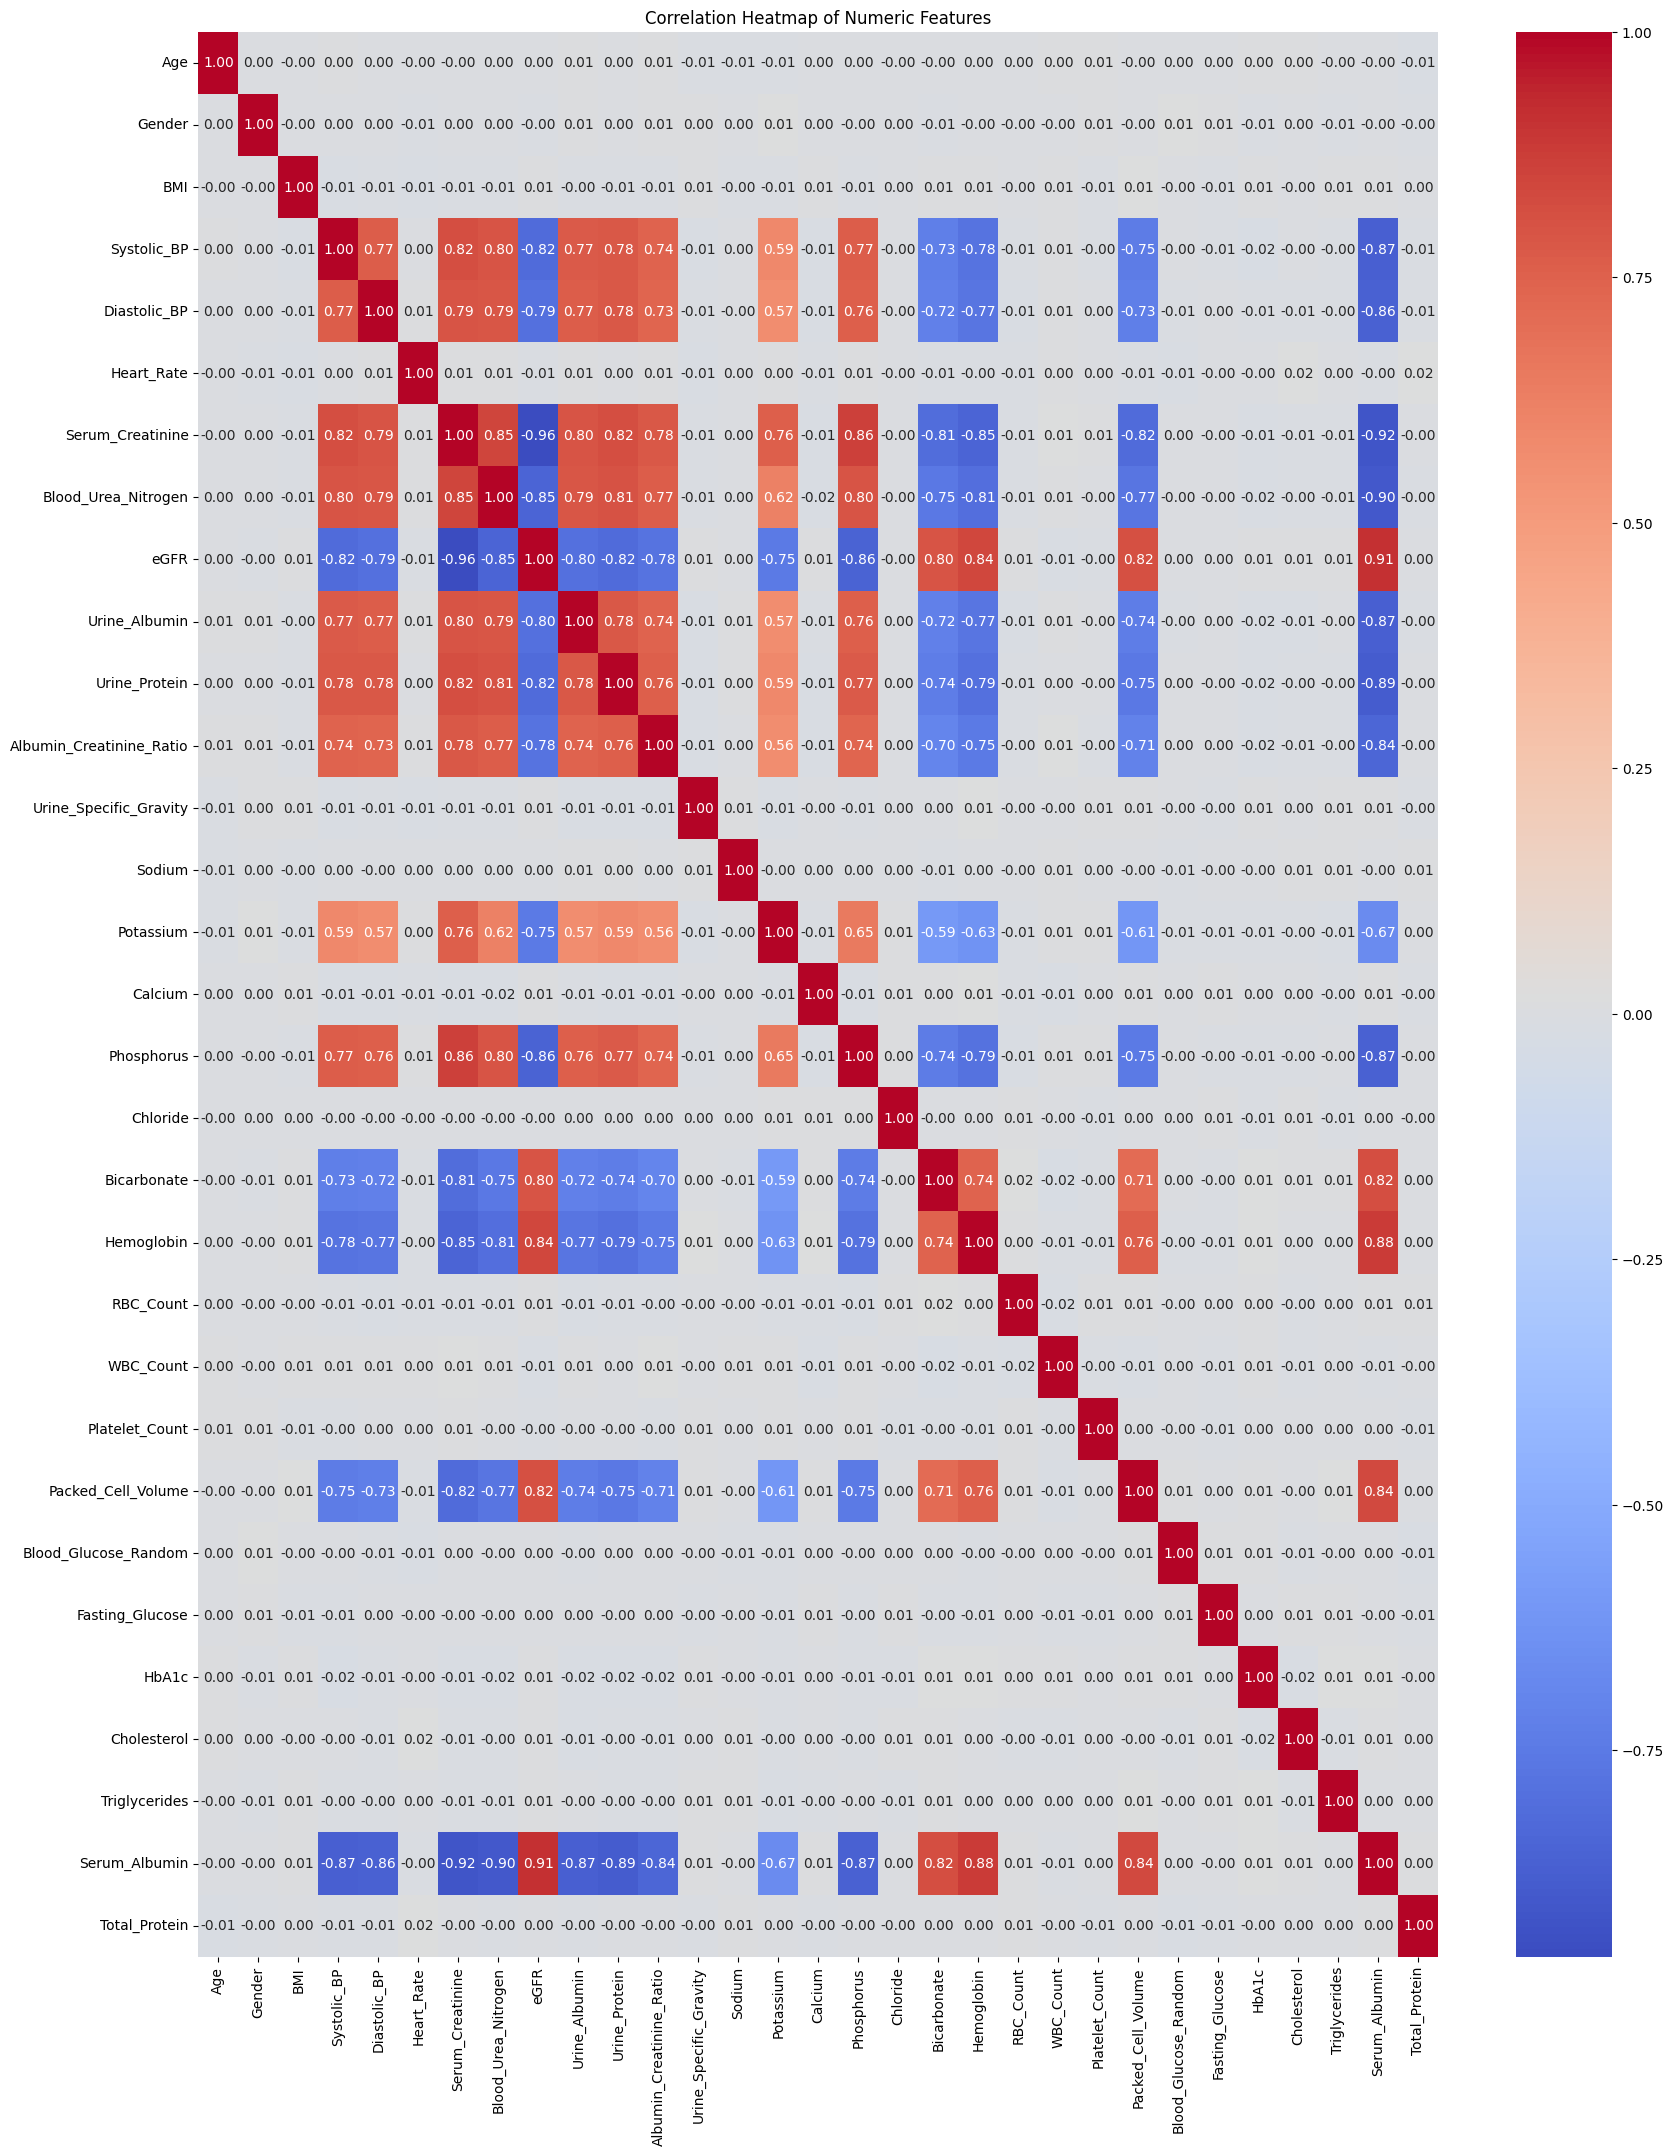

In [20]:
#correlation heatmap for numeric features
plt.figure(figsize=(20, 25))
numeric_features = df_train.select_dtypes(include=[np.number])
correlation_matrix = numeric_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

### We can see that data contain multicolinearity 

### Encode Featurs that contain {'Yes':1,'No':0}

In [21]:
#encode  ["Diabetes","Hypertension","Smoking_Status","Family_History_Kidney"] columns {'Yes': 1, 'No': 0}
df_train['Diabetes'] = df_train['Diabetes'].map({'Yes': 1, 'No': 0})
df_train['Hypertension'] = df_train['Hypertension'].map({'Yes': 1, 'No': 0})
df_train['Smoking_Status'] = df_train['Smoking_Status'].map({'Yes': 1, 'No': 0})
df_train['Family_History_Kidney'] = df_train['Family_History_Kidney'].map({'Yes': 1, 'No': 0})


In [22]:
df_train

,Target,Age,Gender,BMI,Systolic_BP,Diastolic_BP,Heart_Rate,Serum_Creatinine,Blood_Urea_Nitrogen,eGFR,...,Fasting_Glucose,HbA1c,Cholesterol,Triglycerides,Serum_Albumin,Total_Protein,Diabetes,Hypertension,Smoking_Status,Family_History_Kidney
0,Healthy Kidney,29,1,28,4.584967,4.248495,99,0,2.564949,4.564348,...,96,7.547874,204,120,4,7.091259,1,1,1,1
1,Severe CKD (Stage 4),43,0,18,5.111988,4.615121,67,5,4.477337,3.367296,...,88,7.287338,166,277,2,7.875167,1,1,1,0
2,Healthy Kidney,77,0,32,4.762174,4.158883,101,0,2.833213,4.615121,...,82,9.114854,246,299,4,7.083558,0,0,1,0
3,Healthy Kidney,83,0,24,4.543295,4.330733,87,0,2.397895,4.624973,...,82,7.286450,173,285,4,6.428780,1,0,0,1
4,Healthy Kidney,38,1,19,4.718499,4.262680,92,0,2.397895,4.634729,...,106,8.376492,266,294,4,7.852894,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20995,Healthy Kidney,45,0,19,4.595120,4.143135,86,0,2.484907,4.753590,...,124,6.337256,255,275,4,6.536640,0,0,0,0
20996,Mild CKD (Stage 1–2),82,0,20,4.836282,4.406719,88,1,3.218876,4.262680,...,121,4.149633,207,297,3,6.707196,1,1,1,0
20997,Healthy Kidney,65,0,23,4.787492,4.143135,95,0,2.995732,4.663439,...,110,5.738345,249,196,4,6.576637,1,0,1,0
20998,Healthy Kidney,63,0,18,4.770685,4.248495,76,0,2.079442,4.700480,...,95,7.386147,278,231,4,6.030633,0,0,1,1


### see target unique values

In [23]:
#see target unique values and their counts
print(df_train['Target'].value_counts())

Target
Healthy Kidney              15744
Mild CKD (Stage 1–2)         2491
Moderate CKD (Stage 3)       1489
Severe CKD (Stage 4)          856
Kidney Failure (Stage 5)      420
Name: count, dtype: int64


### Draw Class Count

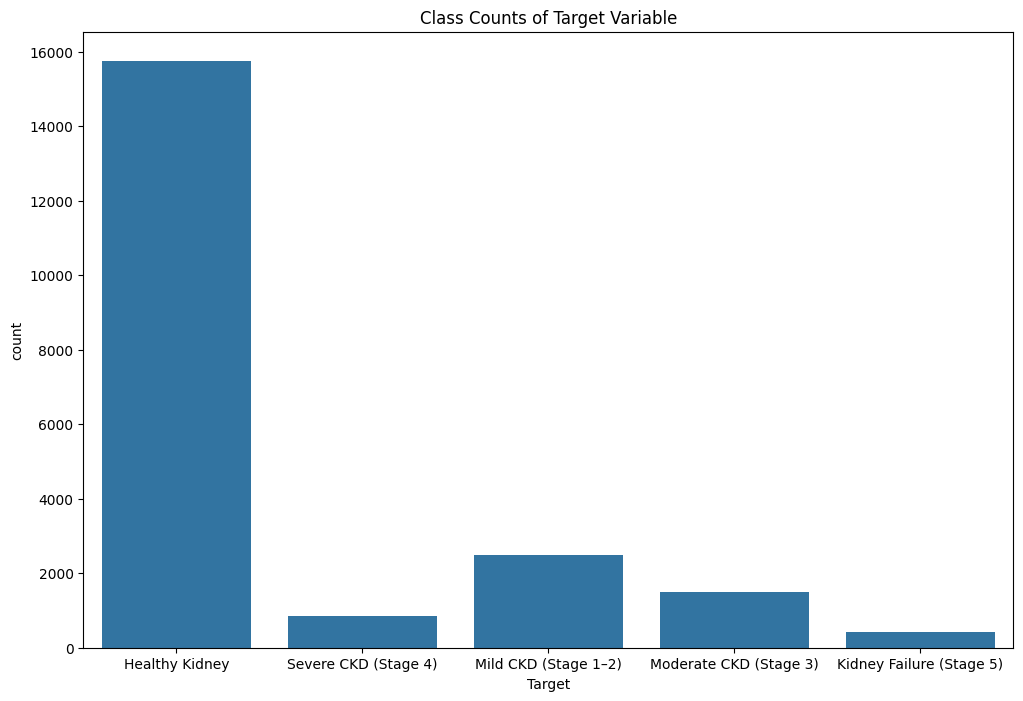

In [24]:
#Draw class Counts
plt.figure(figsize=(12, 8))
sns.countplot(x='Target', data=df_train)
plt.title('Class Counts of Target Variable')
plt.show()

### We can counclude that data is imbalanced so we will deal with weighted data

### set `class_weight='balanced'`

### Advanced Feature Enginering

### Handle Multicollinearity (Drop Redundant Features)
Based on the correlation heatmap, we are dropping features that are highly correlated with others to reduce multicollinearity:
* Dropping `Packed_Cell_Volume` (kept `Hemoglobin`)
* Dropping `Blood_Urea_Nitrogen` (kept `Serum_Creatinine`)
* Dropping `Urine_Protein` and `Albumin_Creatinine_Ratio` (kept `Urine_Albumin`)

In [25]:
# List of highly correlated features to drop
columns_to_drop = [
    'Packed_Cell_Volume', 
    'Blood_Urea_Nitrogen', 
    'Urine_Protein', 
    'Albumin_Creatinine_Ratio'
]

# Drop the columns from the training dataset
df_train = df_train.drop(columns=columns_to_drop)

# Verify the columns were dropped
print(f"Remaining number of columns: {df_train.shape[1]}")

Remaining number of columns: 32


### Encode `Target` feature

In [27]:
# encode Target using ordinal encoding from sklearn
# Healthy Kidney              3615
# Mild CKD (Stage 1–2)         575
# Moderate CKD (Stage 3)       318
# Severe CKD (Stage 4)         196
# Kidney Failure (Stage 5)      96
# Name: count, dtype: int64
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[['Healthy Kidney', 'Mild CKD (Stage 1–2)', 'Moderate CKD (Stage 3)', 'Severe CKD (Stage 4)', 'Kidney Failure (Stage 5)']])
df_train['Target'] = ordinal_encoder.fit_transform(df_train[['Target']])


### Saving preprocessed Data frame 

In [28]:
#save the cleaned and preprocessed training dataset to a new CSV file
df_train.to_csv('Cleaned_Training_CKD_dataset.csv', index=False)

In [30]:
df_train["Target"].unique()

array([0., 3., 1., 2., 4.])

## Start Modeling